In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

log_file = r'c:\Users\ferri\Documents\ProjectesCodi\TFG-truc\entrenament\entrenamentEstatTruc\registres\04_03_26_a_les_2314\logs\preentrenament_log.csv'
df = pd.read_csv(log_file)
df.head()

   iteracio  loss_total  loss_env  loss_truc  loss_acc
0         1    2.259564  1.133832   0.432485  0.693247
1       500    0.222351  0.122038   0.002121  0.098193
2      1000    0.129679  0.074533   0.000978  0.054168
3      1500    0.094491  0.054796   0.000679  0.039015
4      2000    0.078854  0.034529   0.000415  0.043909

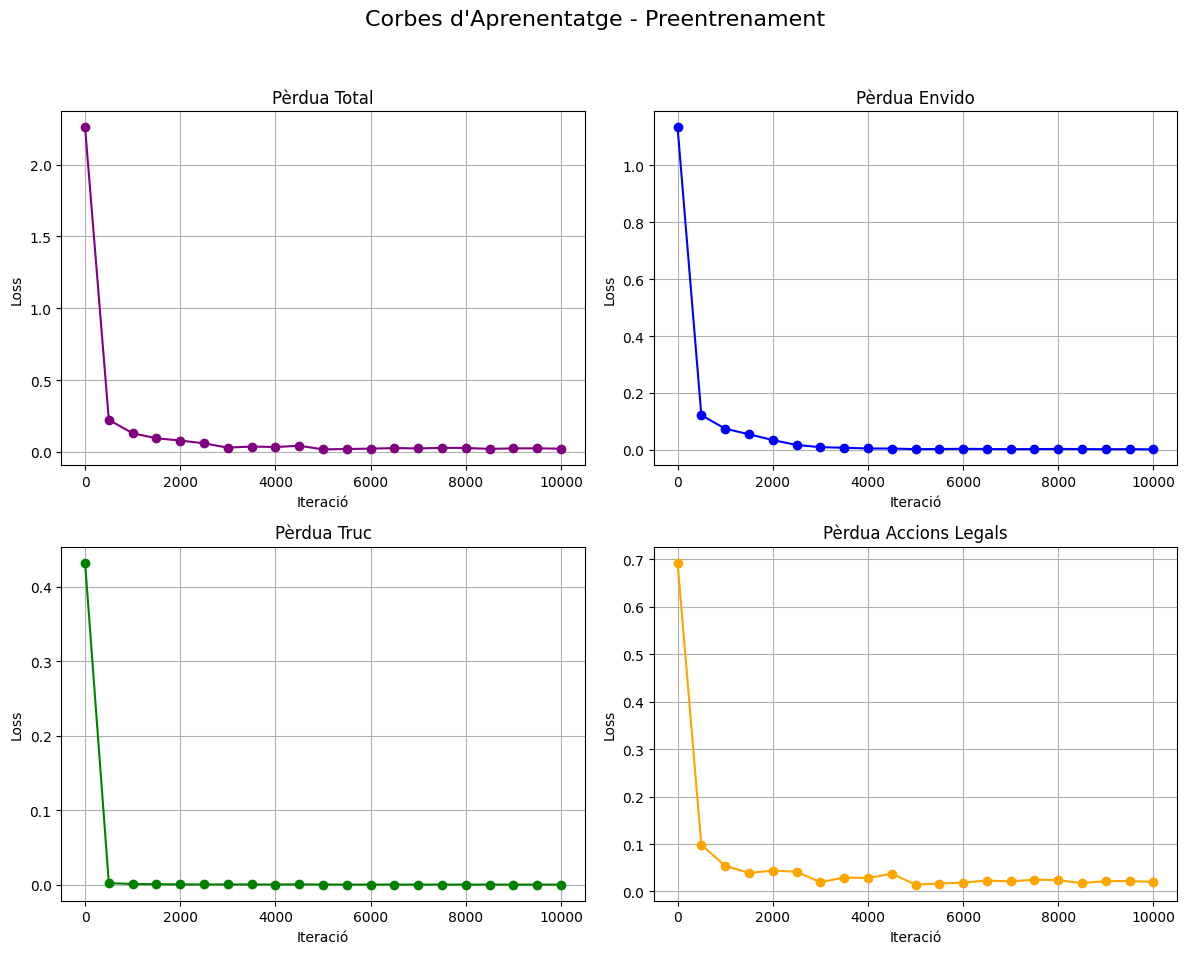

In [2]:
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Corbes d\'Aprenentatge - Preentrenament', fontsize=16)

axs[0, 0].plot(df['iteracio'], df['loss_total'], marker='o', color='purple')
axs[0, 0].set_title('Pèrdua Total')
axs[0, 0].set_xlabel('Iteració')
axs[0, 0].set_ylabel('Loss')
axs[0, 0].grid(True)

axs[0, 1].plot(df['iteracio'], df['loss_env'], marker='o', color='blue')
axs[0, 1].set_title('Pèrdua Envido')
axs[0, 1].set_xlabel('Iteració')
axs[0, 1].set_ylabel('Loss')
axs[0, 1].grid(True)

axs[1, 0].plot(df['iteracio'], df['loss_truc'], marker='o', color='green')
axs[1, 0].set_title('Pèrdua Truc')
axs[1, 0].set_xlabel('Iteració')
axs[1, 0].set_ylabel('Loss')
axs[1, 0].grid(True)

axs[1, 1].plot(df['iteracio'], df['loss_acc'], marker='o', color='orange')
axs[1, 1].set_title('Pèrdua Accions Legals')
axs[1, 1].set_xlabel('Iteració')
axs[1, 1].set_ylabel('Loss')
axs[1, 1].grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Anàlisi dels resultats de l'aprenentatge (Preentrenament)
A partir de les gràfiques generades anteriorment, podem extreure les següents conclusions sobre si el model està aprenent i què està aprenent:

1. **Convergència ràpida**: Totes les funcions de pèrdua (Total, Envido, Truc, Accions legals) baixen dramàticament durant les primeres 1000 iteracions. Això indica que el model és capaç d'aprendre ràpidament els patrons bàsics que es troben en les dades sintètiques del preentrenament.
2. **Què està aprenent?**
   - **Pèrdua Truc**: Arriba a valors molt propers a 0 de forma gairebé immediata. Això suggereix que l'avaluació de la força relacionada en el sub-joc del Truc present al dataset s'aprèn molt fàcilment.
   - **Pèrdua Envido & Accions Legals**: També experimenten una caiguda dràstica inicial i assoleixen l'estabilitat al voltant de la iteració 3000-4000.
   - En general, la xarxa està capturant de manera efectiva les regles fonamentals del joc (com jugar accions legals) i està interioritzant correctament les mètriques d'avaluació (força de l'Envido i Truc) sense massa esforç.
3. **Plataforma d'Estabilització**: A partir de la iteració 4000-5000, els canvis en la pèrdua són mínims, la qual cosa significa que el model ha deixat d'aprendre coses noves o bé ja ha extret i interioritzat tota la informació rellevant disponible al dataset actual.

## Recomanacions per millorar l'entrenament o els resultats
**Implementacions Suggerides:**
* **Early Stopping**: Atès que la pèrdua s'estabilitza prop de la iteració 5000, es podrien estalviar recursos computacionals aturant el preentrenament allà o reduint les iteracions globals, atès que no guanyem precisió significativa més enllà.
* **Augmentar la complexitat de les partides del dataset sintètic**: El fet que la "Loss Truc" sigui gairebé zero en uns pocs passos temporals podria indicar que els exemples de jugades són trivials o els heurístics fets servir tenen poca variància o profunditat (potser falten pautes de *bluff*, pujades arriscades o mans estratègicament subòptimes). 
* **Incorporar un conjunt de validació pur**: Això garantirà que el model aprèn a generalitzar i no fa simple *overfitting* de la sintètica, avaluant la xarxa davant partides inèdites que el model no ha vist durant el bucle en qüestió.
* **Curriculum Learning gradual**: Si hi ha aspectes del joc que triguin naturalment més o siguin complexos de digerir de cop, pots augmentar la proporció de mans difícils al dataset de forma progressiva.
* **Regularització del model**: Segons s'observi quan hi hagi mètrica de *validació testada*, l'overfitting que permet aprendre tan ràpidament patiria caiguda si intentàvem validar dades noves. Introduir o pujar el nivell de l'L2 Weight Decay podria assuavir aquesta memòria pura i centrar la xarxa en representacions més abstractes i útils pel joc real a futur contra humans o a nivell Expert.